# Pipeline Intégrale de Comparaison des Méthodes de Régression SAR

Ce notebook implémente une **pipeline unifiée** qui, à partir d'une description de série temporelle,
produit automatiquement :
1. L'ajustement de toutes les méthodes de régression (spline multiéchelle, spline locale GCV, STL, Fourier)
2. Une analyse comparative : corrélation, amplitude, r/std
3. Une analyse des résidus : gaussianité (Shapiro-Wilk + Q-Q), autocorrélation (ACF + Ljung-Box)
4. Un **tableau récapitulatif final** consolidant tous les critères

## Architecture des données

| Source | Région de référence (régionale) | Signal local | Pipeline |
|--------|--------------------------------|-------------|---------|
| **Subzones Trinité** (`ts_10subzones_defoliated.csv`) | subzone 1 (même paramètres) | subzone N | `full_pipeline_sub` |
| **Trinité régionale** (`ts_s1a_21NZF_*_867km2.csv`) | signal régional 867km² (≡ propre régional) | — | `full_pipeline_reg` |
| **Paracou** (`S1A_ASC-DSC_VV-VH_Paracou/*.csv`) | AllROI | TropiScat | `full_pipeline_ref` |

## Paramétrage rapide

```
SERIES = ["defol", "vh", "DES", 39, 5]    # Subzones Trinité
SERIES = ["vh"]                             # Trinité régionale
SERIES = ["vh", "ASC", "TropiScat"]        # Paracou (local)
SERIES = ["vh", "ASC", "AllROI"]           # Paracou (régional seul)
```


## 1. Imports et configuration

In [1]:
import csv
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from datetime import datetime
import pandas as pd
import os
import warnings
warnings.filterwarnings("ignore")

from scipy.optimize import curve_fit
from scipy import stats
from scipy.signal import find_peaks
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL
from scipy.interpolate import BSpline
import seaborn as sns
from scipy.linalg import lstsq
from scipy.stats import pearsonr

import importlib
import function
importlib.reload(function)
from function import *

sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 12, "axes.titlesize": 13, "legend.fontsize": 11})
os.makedirs("figures_pipeline", exist_ok=True)

print("✓ Imports OK")


✓ Imports OK


## 2. Paramètre d'entrée — à modifier ici uniquement

Choisissez **une** des trois formes de `SERIES` ci-dessous selon la source de données souhaitée.


In [2]:
# ════════════════════════════════════════════════════════════
#  CHOISIR UNE SEULE SOURCE — décommenter la ligne voulue
# ════════════════════════════════════════════════════════════

# ── SOURCE 1 : Subzones Trinité ──────────────────────────────
# SERIES = [type_veg, polarization, direction, orbite, subzone]
# type_veg      : "fol" | "defol" | "nodata"
# polarization  : "vh"  | "vv"
# direction     : "ASC" | "DES"
# orbite        : 39    | 120
# subzone       : 1 … 10  (1 = référence régionale, N = local étudié)
SERIES = ["defol", "vh", "DES", 39, 5]

# ── SOURCE 2 : Trinité régionale (signal 867 km²) ────────────
# SERIES = [polarization]
# polarization : "vh" | "vv"
# SERIES = ["vh"]

# ── SOURCE 3 : Paracou AllROI / TropiScat ───────────────────
# SERIES = [polarization, orbit, region]
# polarization : "vh" | "vv"
# orbit        : "ASC" | "DSC"
# region       : "AllROI" (régional seul) | "TropiScat" (multiéchelle)
# SERIES = ["vh", "DSC", "TropiScat"]

# ════════════════════════════════════════════════════════════
#  PARAMÈTRES GLOBAUX
# ════════════════════════════════════════════════════════════
N_FREQ_LIST  = [2, 3, 4]   # modes harmoniques Fourier à tester
STL_PERIOD   = 30          # acquisitions par cycle annuel (~365/12 jours)
PLOT_FITS    = False       # True pour afficher les graphes intermédiaires

print(f"Série sélectionnée : {SERIES}")
print(f"Modes Fourier      : {N_FREQ_LIST}")
print(f"Période STL        : {STL_PERIOD}")


Série sélectionnée : ['defol', 'vh', 'DES', 39, 5]
Modes Fourier      : [2, 3, 4]
Période STL        : 30


## 3. Extraction des données

In [3]:
# ════════════════════════════════════════════════════════════
#  CHEMINS DES FICHIERS
# ════════════════════════════════════════════════════════════

FILEPATHS_regional = {
    "vv": "data/Data/StudyCase_S1_Trinité/ts_s1a_21NZF_vv_ASC_120_867km2.csv",
    "vh": "data/Data/StudyCase_S1_Trinité/ts_s1a_21NZF_vh_ASC_120_867km2.csv",
}

FILEPATH_local = "data/Data/StudyCase_S1_Trinité/ts_10subzones_defoliated.csv"

FILEPATH_REF = {
    "vv": {
        "ASC": {"047": {"AllROI": "data/Data/S1A_ASC-DSC_VV-VH_Paracou/s1a_vv_ASC_047_allROI.csv",
                        "TropiScat": "data/Data/S1A_ASC-DSC_VV-VH_Paracou/s1a_vv_ASC_047_TropiScat.csv"}},
        "DSC": {"039": {"AllROI": "data/Data/S1A_ASC-DSC_VV-VH_Paracou/s1a_vv_DSC_039_allROI.csv",
                        "TropiScat": "data/Data/S1A_ASC-DSC_VV-VH_Paracou/s1a_vv_DSC_039_TropiScat.csv"}},
    },
    "vh": {
        "ASC": {"047": {"AllROI": "data/Data/S1A_ASC-DSC_VV-VH_Paracou/s1a_vh_ASC_047_allROI.csv",
                        "TropiScat": "data/Data/S1A_ASC-DSC_VV-VH_Paracou/s1a_vh_ASC_047_TropiScat.csv"}},
        "DSC": {"039": {"AllROI": "data/Data/S1A_ASC-DSC_VV-VH_Paracou/s1a_vh_DSC_039_allROI.csv",
                        "TropiScat": "data/Data/S1A_ASC-DSC_VV-VH_Paracou/s1a_vh_DSC_039_TropiScat.csv"}},
    },
}

# ════════════════════════════════════════════════════════════
#  FONCTIONS D'EXTRACTION
# ════════════════════════════════════════════════════════════

def extract_signal_regional(polarization, masking="masked"):
    """Trinité — signal régional 867 km²."""
    polarization = polarization.lower()
    col = f"moy_{masking.lower()}"
    df = pd.read_csv(FILEPATHS_regional[polarization])
    df["date"] = pd.to_datetime(df["date"])
    return df[["date", col]].rename(columns={col: "mean_value"}).sort_values("date").reset_index(drop=True)


def extract_signal_local_log(subzone, type_veg, polarization, orbite, direction, satellite=None):
    """Trinité — subzones (conversion linéaire → dB)."""
    def to_list(v): return [v] if not isinstance(v, list) else v
    df = pd.read_csv(FILEPATH_local)
    df["subzone_id"] = df["shapefile_name"].str.extract(r"subzone(\d+)").astype(int)
    mask = (df["subzone_id"].isin(to_list(subzone)) & df["type"].isin(to_list(type_veg)) &
            df["polarization"].isin(to_list(polarization)) & df["orbite"].isin(to_list(orbite)) &
            df["direction"].isin(to_list(direction)))
    if satellite is not None:
        mask &= df["satellite"].isin(to_list(satellite))
    df = df[mask].copy()
    df["date"] = pd.to_datetime(df["date"], format="%Y%m%d")
    df["mean_value"] = 10 * np.log10(df["mean_value"])
    return df[["date", "mean_value"]].sort_values("date").reset_index(drop=True)


def extract_signal_ref(polarization, orbit, region="AllROI"):
    """Paracou — AllROI ou TropiScat."""
    polarization = polarization.lower(); orbit = orbit.upper()
    rel = "047" if orbit == "ASC" else "039"
    fp = FILEPATH_REF[polarization][orbit][rel][region]
    df = pd.read_csv(fp)
    df["date"] = pd.to_datetime(df["time"])
    return df[["date", "value"]].rename(columns={"value": "mean_value"}).sort_values("date").reset_index(drop=True)

print("✓ Fonctions d'extraction définies")


✓ Fonctions d'extraction définies


## 4. Fonctions de régression

In [4]:
ALPHA = 3.0  # Mallows Cp

def run_regional_spline(ts, use_mallows=False, plot=False):
    """Spline pénalisée sur le signal régional. Retourne λ et σ pour transfert."""
    dates  = pd.to_datetime(ts["date"].values)
    values = ts["mean_value"].values
    t = np.array([(d - dates[0]).days for d in dates], dtype=float)
    if use_mallows:
        n_knots, _ = stepwise_knot_selection_bspline(t, values, alpha=ALPHA)
    else:
        n_knots = len(ts)
    B = build_bspline_basis(t, n_knots)
    lam = optimize_lambda_gcv(B, values)
    _, Y_hat = penalized_spline_fit(B, values, lam)
    if plot:
        plt.figure(figsize=(14, 4))
        plt.plot(dates, values, "-o", alpha=0.45, markersize=3, color="tab:blue", label="Signal")
        plt.plot(dates, Y_hat, color="tomato", lw=2, label=f"Spline régionale | λ={lam:.2e}")
        plt.title("Spline régionale"); plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
    return {"dates": dates, "values": values, "t": t, "n_knots": n_knots,
            "lam": lam, "Y_hat": Y_hat, "reg_std": np.std(values)}


def run_local_spline(ts, lam_regional, std_regional, plot=False):
    """Spline locale — deux variantes : λ GCV et λ transféré depuis le régional."""
    dates  = pd.to_datetime(ts["date"].values)
    values = ts["mean_value"].values
    t = np.array([(d - dates[0]).days for d in dates], dtype=float)
    n_knots = len(ts)
    std_loc = np.std(values)
    B = build_bspline_basis(t, n_knots)
    lam_gcv = optimize_lambda_gcv(B, values)
    _, Y_gcv = penalized_spline_fit(B, values, lam_gcv)
    lam_reg = (std_loc / std_regional) ** 2 * lam_regional
    _, Y_reg = penalized_spline_fit(B, values, lam_reg)
    if plot:
        plt.figure(figsize=(14, 4))
        plt.plot(dates, values, "-o", alpha=0.45, markersize=3, color="tab:blue", label="Signal")
        plt.plot(dates, Y_gcv, color="tomato",   lw=2, label=f"Spline GCV | λ={lam_gcv:.2e}")
        plt.plot(dates, Y_reg, color="seagreen", lw=2, ls="--", label=f"Spline λ-régional | λ={lam_reg:.2e}")
        plt.title("Spline locale"); plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
    return {"dates": dates, "values": values, "t": t, "n_knots": n_knots,
            "lam_gcv": lam_gcv, "Y_hat_gcv": Y_gcv, "lam_reg": lam_reg, "Y_hat_reg": Y_reg}


def run_stl(ts, period=30, plot=False):
    """Décomposition STL. Retourne Trend+Seasonal comme signal reconstruit."""
    dates  = pd.to_datetime(ts["date"].values)
    values = ts["mean_value"].values
    result = STL(pd.Series(values, index=dates), period=period, robust=True).fit()
    Y_stl = result.trend + result.seasonal
    if plot:
        plt.figure(figsize=(14, 4))
        plt.plot(dates, values, "-o", alpha=0.45, markersize=3, color="tab:blue", label="Signal")
        plt.plot(dates, Y_stl, color="mediumpurple", lw=2, label=f"STL | period={period}")
        plt.title("STL"); plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
    return {"Y_stl": Y_stl}


def make_fourier_model(omegas_fixed):
    def fourier_model_fixed(t, a, b, c, *coeffs):
        y = a + b * t + c * t**2
        for i in range(len(coeffs) // 2):
            y += coeffs[2*i] * np.sin(omegas_fixed[i] * t) + coeffs[2*i+1] * np.cos(omegas_fixed[i] * t)
        return y
    return fourier_model_fixed


def run_fourier(ts, n_freq_list=None, plot=False):
    """Fourier multiéchelle : fréquences Welch sur le signal local, ajustement contraint."""
    if n_freq_list is None: n_freq_list = [2, 3, 4]
    dates  = pd.to_datetime(ts["date"].values)
    values = ts["mean_value"].values
    t = np.array([(d - dates[0]).days for d in dates], dtype=float)
    fs = 1 / 12
    nperseg = min(int(730 / 12), len(values))
    freqs_w, psd_w = signal.welch(values, fs=fs, window="hann",
                                   nperseg=nperseg, noverlap=nperseg//2, scaling="density")
    y_fits = {}
    for n_freq in n_freq_list:
        top_idx = np.argsort(psd_w[1:])[::-1][:n_freq] + 1
        omegas  = 2 * np.pi * freqs_w[top_idx]
        model   = make_fourier_model(omegas)
        p0      = [values.mean(), 0.0, 0.0] + [0.1, 0.1] * n_freq
        try:
            params, _ = curve_fit(model, t, values, p0=p0, maxfev=20000)
            y_fit = model(t, *params)
            if plot:
                plt.figure(figsize=(14, 4))
                plt.plot(dates, values, "-o", alpha=0.45, markersize=3, color="tab:blue", label="Signal")
                plt.plot(dates, y_fit, color="darkorange", lw=2, label=f"Fourier n={n_freq}")
                plt.title(f"Fourier n={n_freq}"); plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
            y_fits[n_freq] = y_fit
        except RuntimeError as e:
            print(f"  ⚠ Fourier n={n_freq} : convergence échouée ({e})")
    return {"y_fits": y_fits}

print("✓ Fonctions de régression définies")


✓ Fonctions de régression définies


## 5. Pipeline intégrale

La fonction `run_full_pipeline` détecte automatiquement la source à partir de la forme de `SERIES`
et route vers l'extraction et le couplage régional/local approprié.


In [5]:
def _detect_source(SERIES):
    """Détecte la source de données à partir de la forme de SERIES.
    Retourne : 'subzone' | 'trinite_reg' | 'paracou'
    """
    if len(SERIES) == 5:
        return "subzone"
    if len(SERIES) == 1:
        return "trinite_reg"
    if len(SERIES) == 3:
        return "paracou"
    raise ValueError(f"Format SERIES non reconnu : {SERIES}. "
                     "Attendu : [type,pol,dir,orb,sub] | [pol] | [pol,orbit,region]")


def _load_data(SERIES):
    """
    Charge le signal local (à ajuster) et la référence régionale (pour transfert λ).
    Retourne :
        ts_local     : DataFrame [date, mean_value]  — signal à modéliser
        ts_regional  : DataFrame [date, mean_value]  — référence pour spline multiéchelle
        source       : str  — identifiant de la source
        has_multiscale : bool — True si le couplage régional→local a du sens
        label        : str  — description lisible pour les titres
    """
    source = _detect_source(SERIES)

    if source == "subzone":
        type_veg, pol, direction, orbite, subzone = SERIES
        # Régionale = subzone 1 (même modalités, emprise plus large / référence du professeur)
        ts_regional = extract_signal_local_log(
            subzone=1, type_veg=type_veg, polarization=pol, orbite=orbite, direction=direction)
        # Locale = subzone demandée
        ts_local = extract_signal_local_log(
            subzone=subzone, type_veg=type_veg, polarization=pol, orbite=orbite, direction=direction)
        label = f"Subzones Trinité — {pol.upper()} {direction} orb{orbite} | type={type_veg} | zone={subzone}"
        return ts_local, ts_regional, source, True, label

    if source == "trinite_reg":
        pol = SERIES[0]
        ts_regional = extract_signal_regional(pol, "masked")
        # Pas de signal local distinct : on analyse le signal régional lui-même
        ts_local = ts_regional
        label = f"Trinité régionale 867km² — {pol.upper()}"
        # Pas de transfert multiéchelle (une seule échelle)
        return ts_local, ts_regional, source, False, label

    if source == "paracou":
        pol, orbit, region = SERIES
        ts_regional = extract_signal_ref(pol, orbit, region="AllROI")
        if region == "AllROI":
            ts_local = ts_regional
            has_multiscale = False
            label = f"Paracou AllROI — {pol.upper()} {orbit.upper()}"
        else:
            ts_local = extract_signal_ref(pol, orbit, region=region)
            has_multiscale = True
            label = f"Paracou {region} — {pol.upper()} {orbit.upper()}"
        return ts_local, ts_regional, source, has_multiscale, label

    raise ValueError(f"Source inconnue : {source}")


def run_full_pipeline(SERIES, n_freq_list=None, stl_period=30, plot_fits=False):
    """
    Pipeline intégrale.

    Paramètres
    ----------
    SERIES       : liste décrivant la série (voir cellule 2)
    n_freq_list  : modes Fourier à tester, défaut [2, 3, 4]
    stl_period   : période STL (acquisitions / cycle annuel), défaut 30
    plot_fits    : afficher les graphes intermédiaires des fits

    Retourne
    --------
    dict avec : label, source, dates, values, fits, residuals, metrics
    """
    if n_freq_list is None: n_freq_list = [2, 3, 4]

    # ── 1. Chargement ────────────────────────────────────────────────────────
    ts_local, ts_regional, source, has_multiscale, label = _load_data(SERIES)
    dates  = pd.to_datetime(ts_local["date"].values)
    values = np.array(ts_local["mean_value"].values, dtype=float)
    print(f"\n{'─'*65}")
    print(f"  Série  : {label}")
    print(f"  Source : {source}  |  multiéchelle : {has_multiscale}")
    print(f"  Points : {len(values)}  ({dates[0].date()} → {dates[-1].date()})")
    print(f"{'─'*65}")

    # ── 2. Spline régionale (pour transfert λ) ────────────────────────────────
    res_reg  = run_regional_spline(ts_regional, use_mallows=False, plot=False)
    lam_reg  = res_reg["lam"]
    std_reg  = res_reg["reg_std"]

    # ── 3. Ajustements ───────────────────────────────────────────────────────
    fits = {}

    # Spline multiéchelle (λ transféré) — uniquement si couplage pertinent
    if has_multiscale:
        loc_sp = run_local_spline(ts_local, lam_reg, std_reg, plot=plot_fits)
        fits["Spline multiéchelle"]  = loc_sp["Y_hat_reg"]
        fits["Spline locale (GCV)"]  = loc_sp["Y_hat_gcv"]
        print(f"  ✓ Spline multiéchelle  λ_reg={lam_reg:.2e}  λ_loc={loc_sp['lam_reg']:.2e}")
        print(f"  ✓ Spline locale GCV    λ_gcv={loc_sp['lam_gcv']:.2e}")
    else:
        # Une seule échelle : on fait uniquement la spline GCV locale
        loc_sp = run_local_spline(ts_local, lam_reg, std_reg, plot=plot_fits)
        fits["Spline (GCV)"] = loc_sp["Y_hat_gcv"]
        print(f"  ✓ Spline GCV  λ={loc_sp['lam_gcv']:.2e}  (pas de transfert régional)")

    # STL
    stl_res = run_stl(ts_local, period=stl_period, plot=plot_fits)
    fits["STL"] = stl_res["Y_stl"]
    print(f"  ✓ STL  (period={stl_period})")

    # Fourier
    fou_res = run_fourier(ts_local, n_freq_list=n_freq_list, plot=plot_fits)
    for n_f, y_f in fou_res["y_fits"].items():
        fits[f"Fourier n={n_f}"] = y_f
        print(f"  ✓ Fourier n={n_f}")

    # ── 4. Résidus & métriques ────────────────────────────────────────────────
    residuals = {}
    metrics   = {}
    for name, y_fit in fits.items():
        res    = values - np.array(y_fit)
        ss_res = np.sum(res**2)
        ss_tot = np.sum((values - values.mean())**2)
        r2     = 1 - ss_res / ss_tot
        rmse   = np.sqrt(np.mean(res**2))
        sw_w, sw_p = stats.shapiro(res)
        lb = acorr_ljungbox(res, lags=20, return_df=True)
        lb_p = lb["lb_pvalue"].min()
        # corrélation avec le signal original
        r_corr, _ = pearsonr(values, np.array(y_fit))
        # amplitude (peaks - valleys)
        pk, _ = find_peaks( y_fit, prominence=0.1, distance=10)
        vl, _ = find_peaks(-np.array(y_fit), prominence=0.1, distance=10)
        amp = (np.mean(np.array(y_fit)[pk]) - np.mean(np.array(y_fit)[vl])
               if len(pk) > 0 and len(vl) > 0 else np.nan)
        residuals[name] = res
        metrics[name] = {
            "R²":                  r2,
            "RMSE [dB]":           rmse,
            "σ résidus [dB]":      res.std(),
            "μ résidus [dB]":      res.mean(),
            "Corrélation r":       r_corr,
            "r / std":             r_corr / np.std(y_fit) if np.std(y_fit) > 0 else np.nan,
            "Amplitude [dB]":      amp,
            "Shapiro W":           sw_w,
            "Shapiro p":           sw_p,
            "Gaussien (p>0.05)":   "✓" if sw_p  > 0.05 else "✗",
            "Ljung-Box p_min":     lb_p,
            "Bruit blanc (p>0.05)": "✓" if lb_p  > 0.05 else "✗",
        }

    print(f"\n  ✓ Métriques calculées pour {len(fits)} méthodes")

    return {
        "label"     : label,
        "source"    : source,
        "dates"     : dates,
        "values"    : values,
        "fits"      : fits,
        "residuals" : residuals,
        "metrics"   : metrics,
        "has_multiscale": has_multiscale,
    }

print("✓ Pipeline définie")


✓ Pipeline définie


## 6. Exécution

In [6]:
results = run_full_pipeline(
    SERIES,
    n_freq_list = N_FREQ_LIST,
    stl_period  = STL_PERIOD,
    plot_fits   = PLOT_FITS,
)



─────────────────────────────────────────────────────────────────
  Série  : Subzones Trinité — VH DES orb39 | type=defol | zone=5
  Source : subzone  |  multiéchelle : True
  Points : 266  (2017-02-06 → 2025-10-22)
─────────────────────────────────────────────────────────────────
  ✓ Spline multiéchelle  λ_reg=1.48e+01  λ_loc=1.77e+01
  ✓ Spline locale GCV    λ_gcv=6.58e+01
  ✓ STL  (period=30)
  ✓ Fourier n=2
  ✓ Fourier n=3
  ✓ Fourier n=4

  ✓ Métriques calculées pour 6 méthodes


## 7. Vue d'ensemble — tous les ajustements

Un seul graphe superposant le signal original et tous les fits.


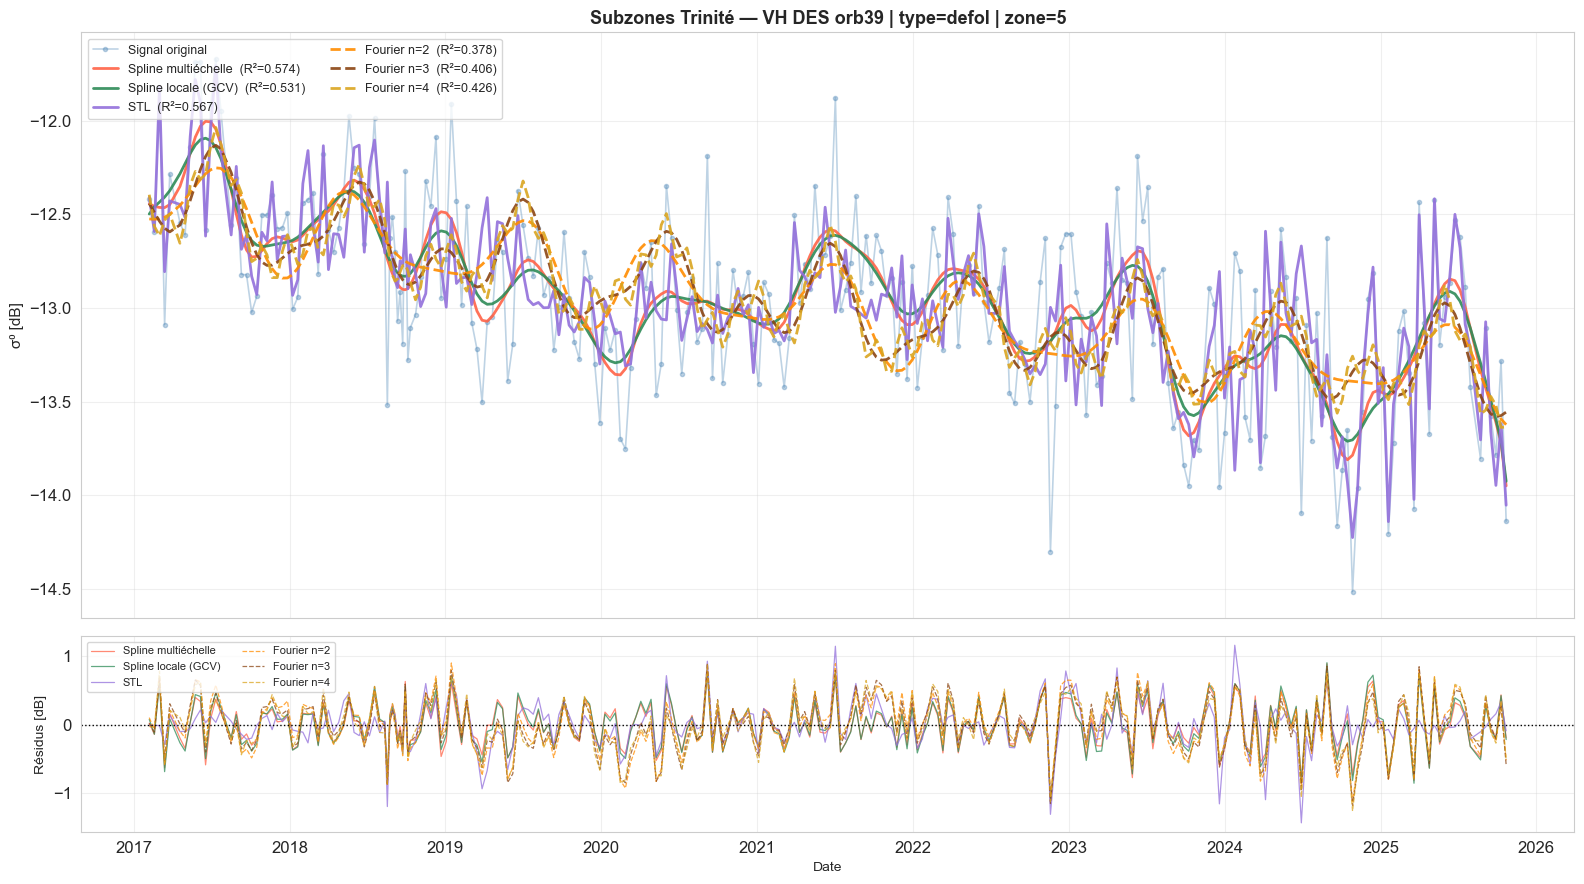

In [7]:
dates  = results["dates"]
values = results["values"]
fits   = results["fits"]
label  = results["label"]

COLORS = {
    "Spline multiéchelle" : "tomato",
    "Spline locale (GCV)" : "seagreen",
    "Spline (GCV)"        : "seagreen",
    "STL"                 : "mediumpurple",
}
FOURIER_PALETTE = ["darkorange", "saddlebrown", "goldenrod"]

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})

ax = axes[0]
ax.plot(dates, values, "-o", lw=1.2, alpha=0.35, markersize=3,
        color="steelblue", label="Signal original", zorder=1)

fou_idx = 0
for name, y_fit in fits.items():
    if "Fourier" in name:
        color = FOURIER_PALETTE[fou_idx % len(FOURIER_PALETTE)]
        fou_idx += 1
        ls = "--"
    else:
        color = COLORS.get(name, "gray")
        ls = "-"
    r2 = results["metrics"][name]["R²"]
    ax.plot(dates, y_fit, ls=ls, lw=2.0, color=color,
            label=f"{name}  (R²={r2:.3f})", alpha=0.9)

ax.set_ylabel("σ⁰ [dB]", fontsize=11)
ax.set_title(f"{label}", fontsize=13, fontweight="bold")
ax.legend(loc="upper left", fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

# Résidus superposés (panneau bas)
ax2 = axes[1]
fou_idx = 0
for name, res in results["residuals"].items():
    if "Fourier" in name:
        color = FOURIER_PALETTE[fou_idx % len(FOURIER_PALETTE)]
        fou_idx += 1
        ls = "--"
    else:
        color = COLORS.get(name, "gray")
        ls = "-"
    ax2.plot(dates, res, ls=ls, lw=0.9, color=color, alpha=0.75, label=name)
ax2.axhline(0, color="black", lw=1, ls=":")
ax2.set_ylabel("Résidus [dB]", fontsize=10)
ax2.set_xlabel("Date", fontsize=10)
ax2.legend(loc="upper left", fontsize=8, ncol=2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures_pipeline/01_fits_overview.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Analyse des résidus

### 8.1 Gaussianité (histogrammes + Q-Q plots)


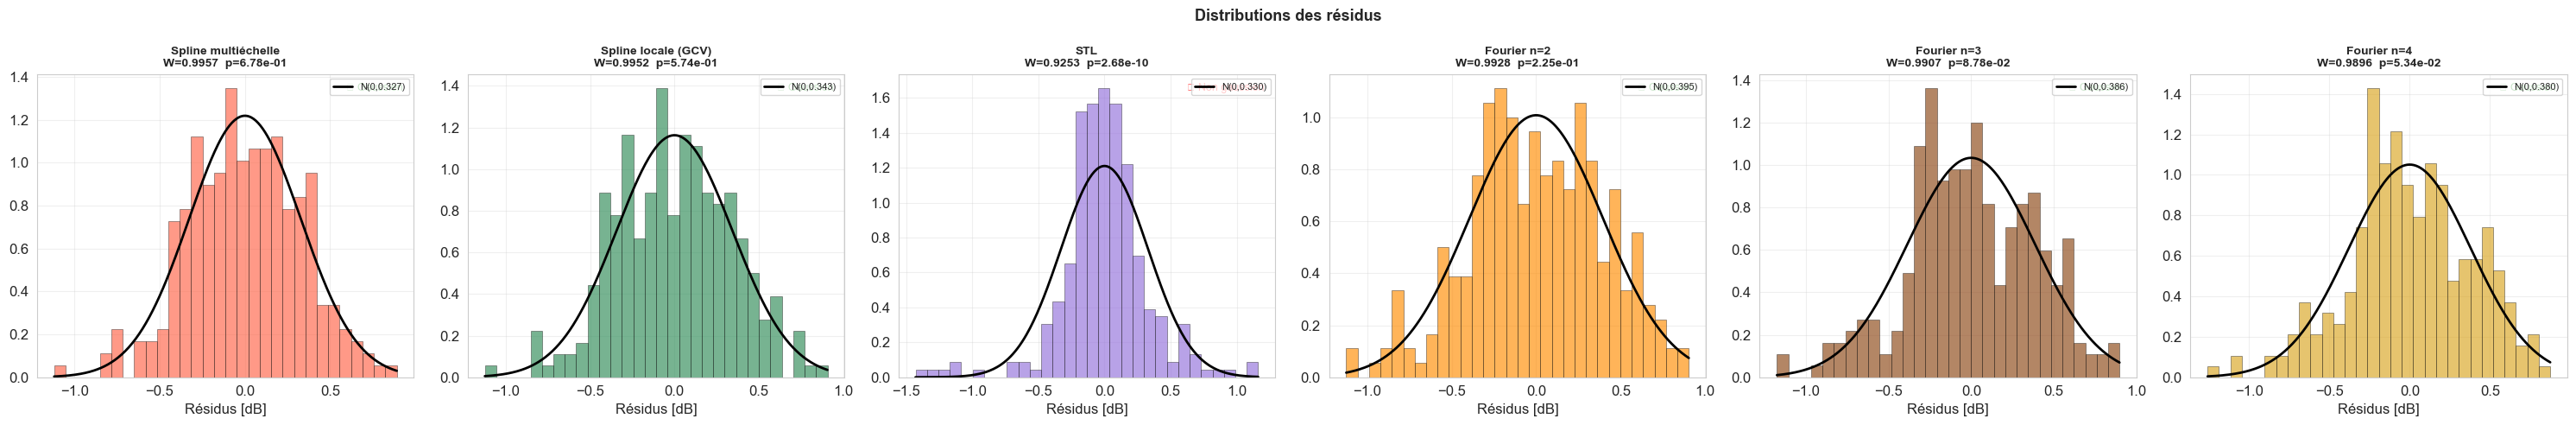

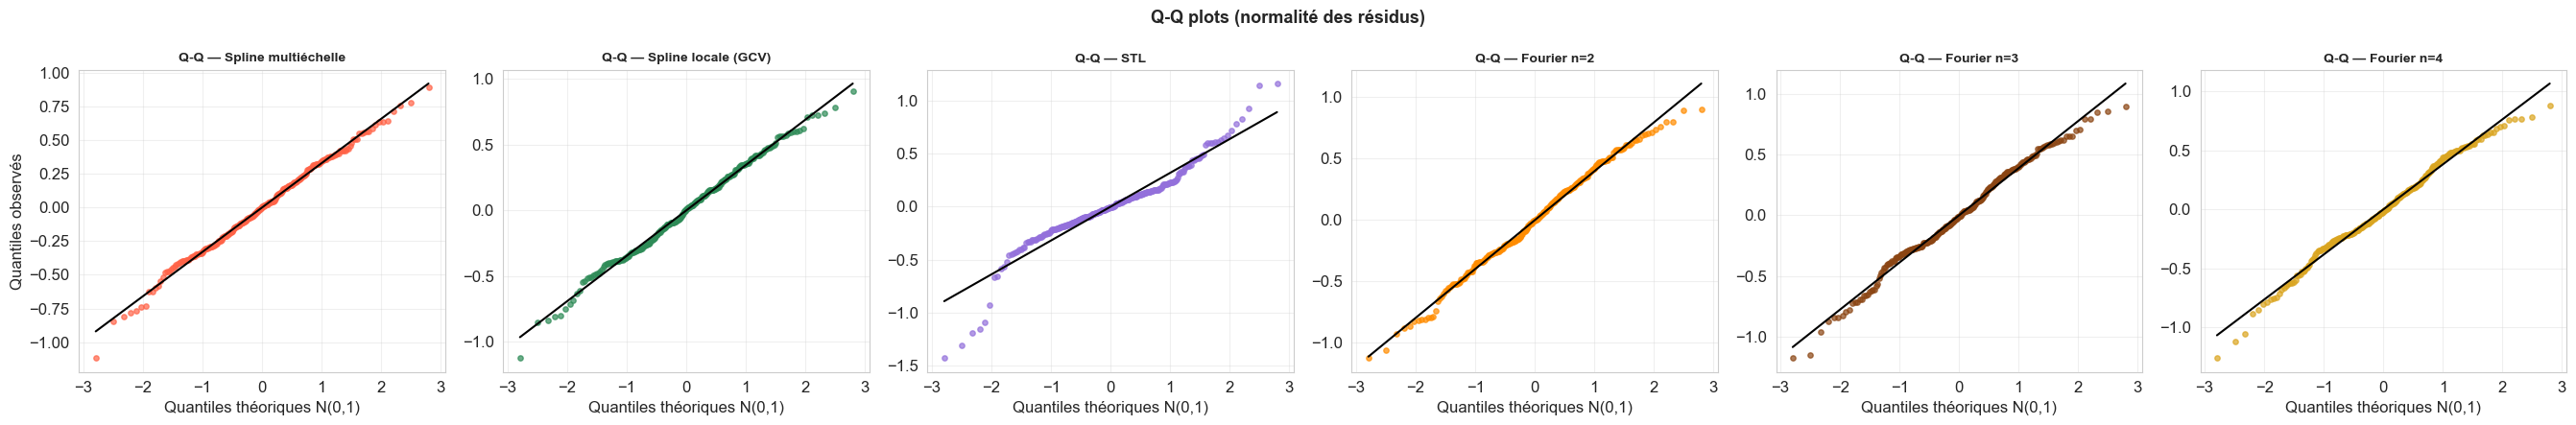

In [8]:
residuals = results["residuals"]
n_methods = len(residuals)

COLORS_RES = {
    "Spline multiéchelle" : "tomato",
    "Spline locale (GCV)" : "seagreen",
    "Spline (GCV)"        : "seagreen",
    "STL"                 : "mediumpurple",
}
fou_palette = ["darkorange", "saddlebrown", "goldenrod"]

def get_color(name, _cache={"fi": 0}):
    if "Fourier" in name:
        c = fou_palette[_cache["fi"] % len(fou_palette)]
        _cache["fi"] += 1
        return c
    return COLORS_RES.get(name, "slategray")

method_names = list(residuals.keys())
colors_list  = []
_fi = 0
for n in method_names:
    if "Fourier" in n:
        colors_list.append(fou_palette[_fi % len(fou_palette)])
        _fi += 1
    else:
        colors_list.append(COLORS_RES.get(n, "slategray"))

# ── Histogrammes ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, n_methods, figsize=(5 * n_methods, 5), sharey=False)
if n_methods == 1: axes = [axes]

for ax, (name, res), color in zip(axes, residuals.items(), colors_list):
    sw_w, sw_p = results["metrics"][name]["Shapiro W"], results["metrics"][name]["Shapiro p"]
    ax.hist(res, bins=30, density=True, alpha=0.65, color=color, edgecolor="black", lw=0.4)
    xr = np.linspace(res.min(), res.max(), 300)
    ax.plot(xr, stats.norm.pdf(xr, 0, res.std()), "k-", lw=2, label=f"N(0,{res.std():.3f})")
    verdict = "✓ Gaussien" if sw_p > 0.05 else "✗ Non gaussien"
    ax.text(0.97, 0.97, verdict, transform=ax.transAxes, ha="right", va="top",
            fontsize=9, color="green" if sw_p > 0.05 else "red",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))
    ax.set_title(f"{name}\nW={sw_w:.4f}  p={sw_p:.2e}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Résidus [dB]"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle("Distributions des résidus", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures_pipeline/02_hist_gaussianite.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Q-Q plots ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, n_methods, figsize=(4.5 * n_methods, 4.5))
if n_methods == 1: axes = [axes]

for ax, (name, res), color in zip(axes, residuals.items(), colors_list):
    (osm, osr), (slope, intercept, _) = stats.probplot(res, dist="norm")
    ax.scatter(osm, osr, color=color, s=15, alpha=0.7)
    ax.plot(osm, slope * np.array(osm) + intercept, "k-", lw=1.5)
    ax.set_title(f"Q-Q — {name}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Quantiles théoriques N(0,1)")
    ax.set_ylabel("Quantiles observés" if ax == axes[0] else "")
    ax.grid(True, alpha=0.3)

plt.suptitle("Q-Q plots (normalité des résidus)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures_pipeline/03_qqplots.png", dpi=150, bbox_inches="tight")
plt.show()


### 8.2 Autocorrélation (ACF + Ljung-Box)

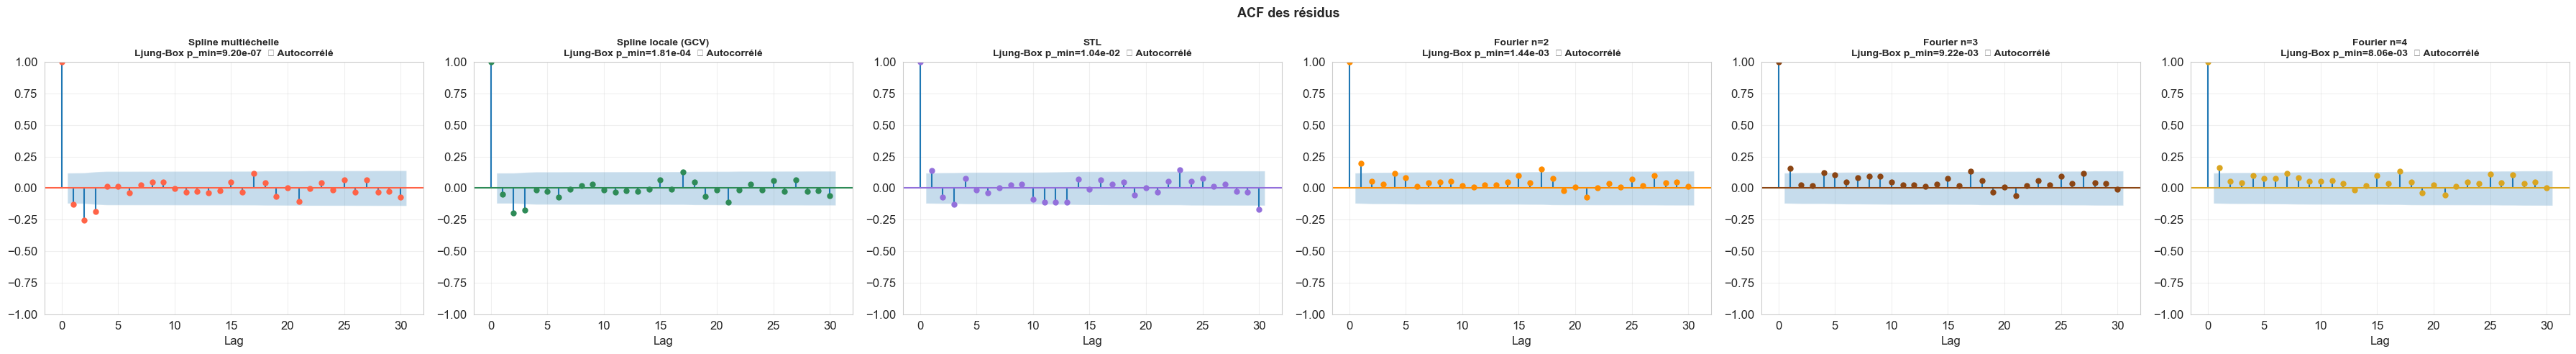

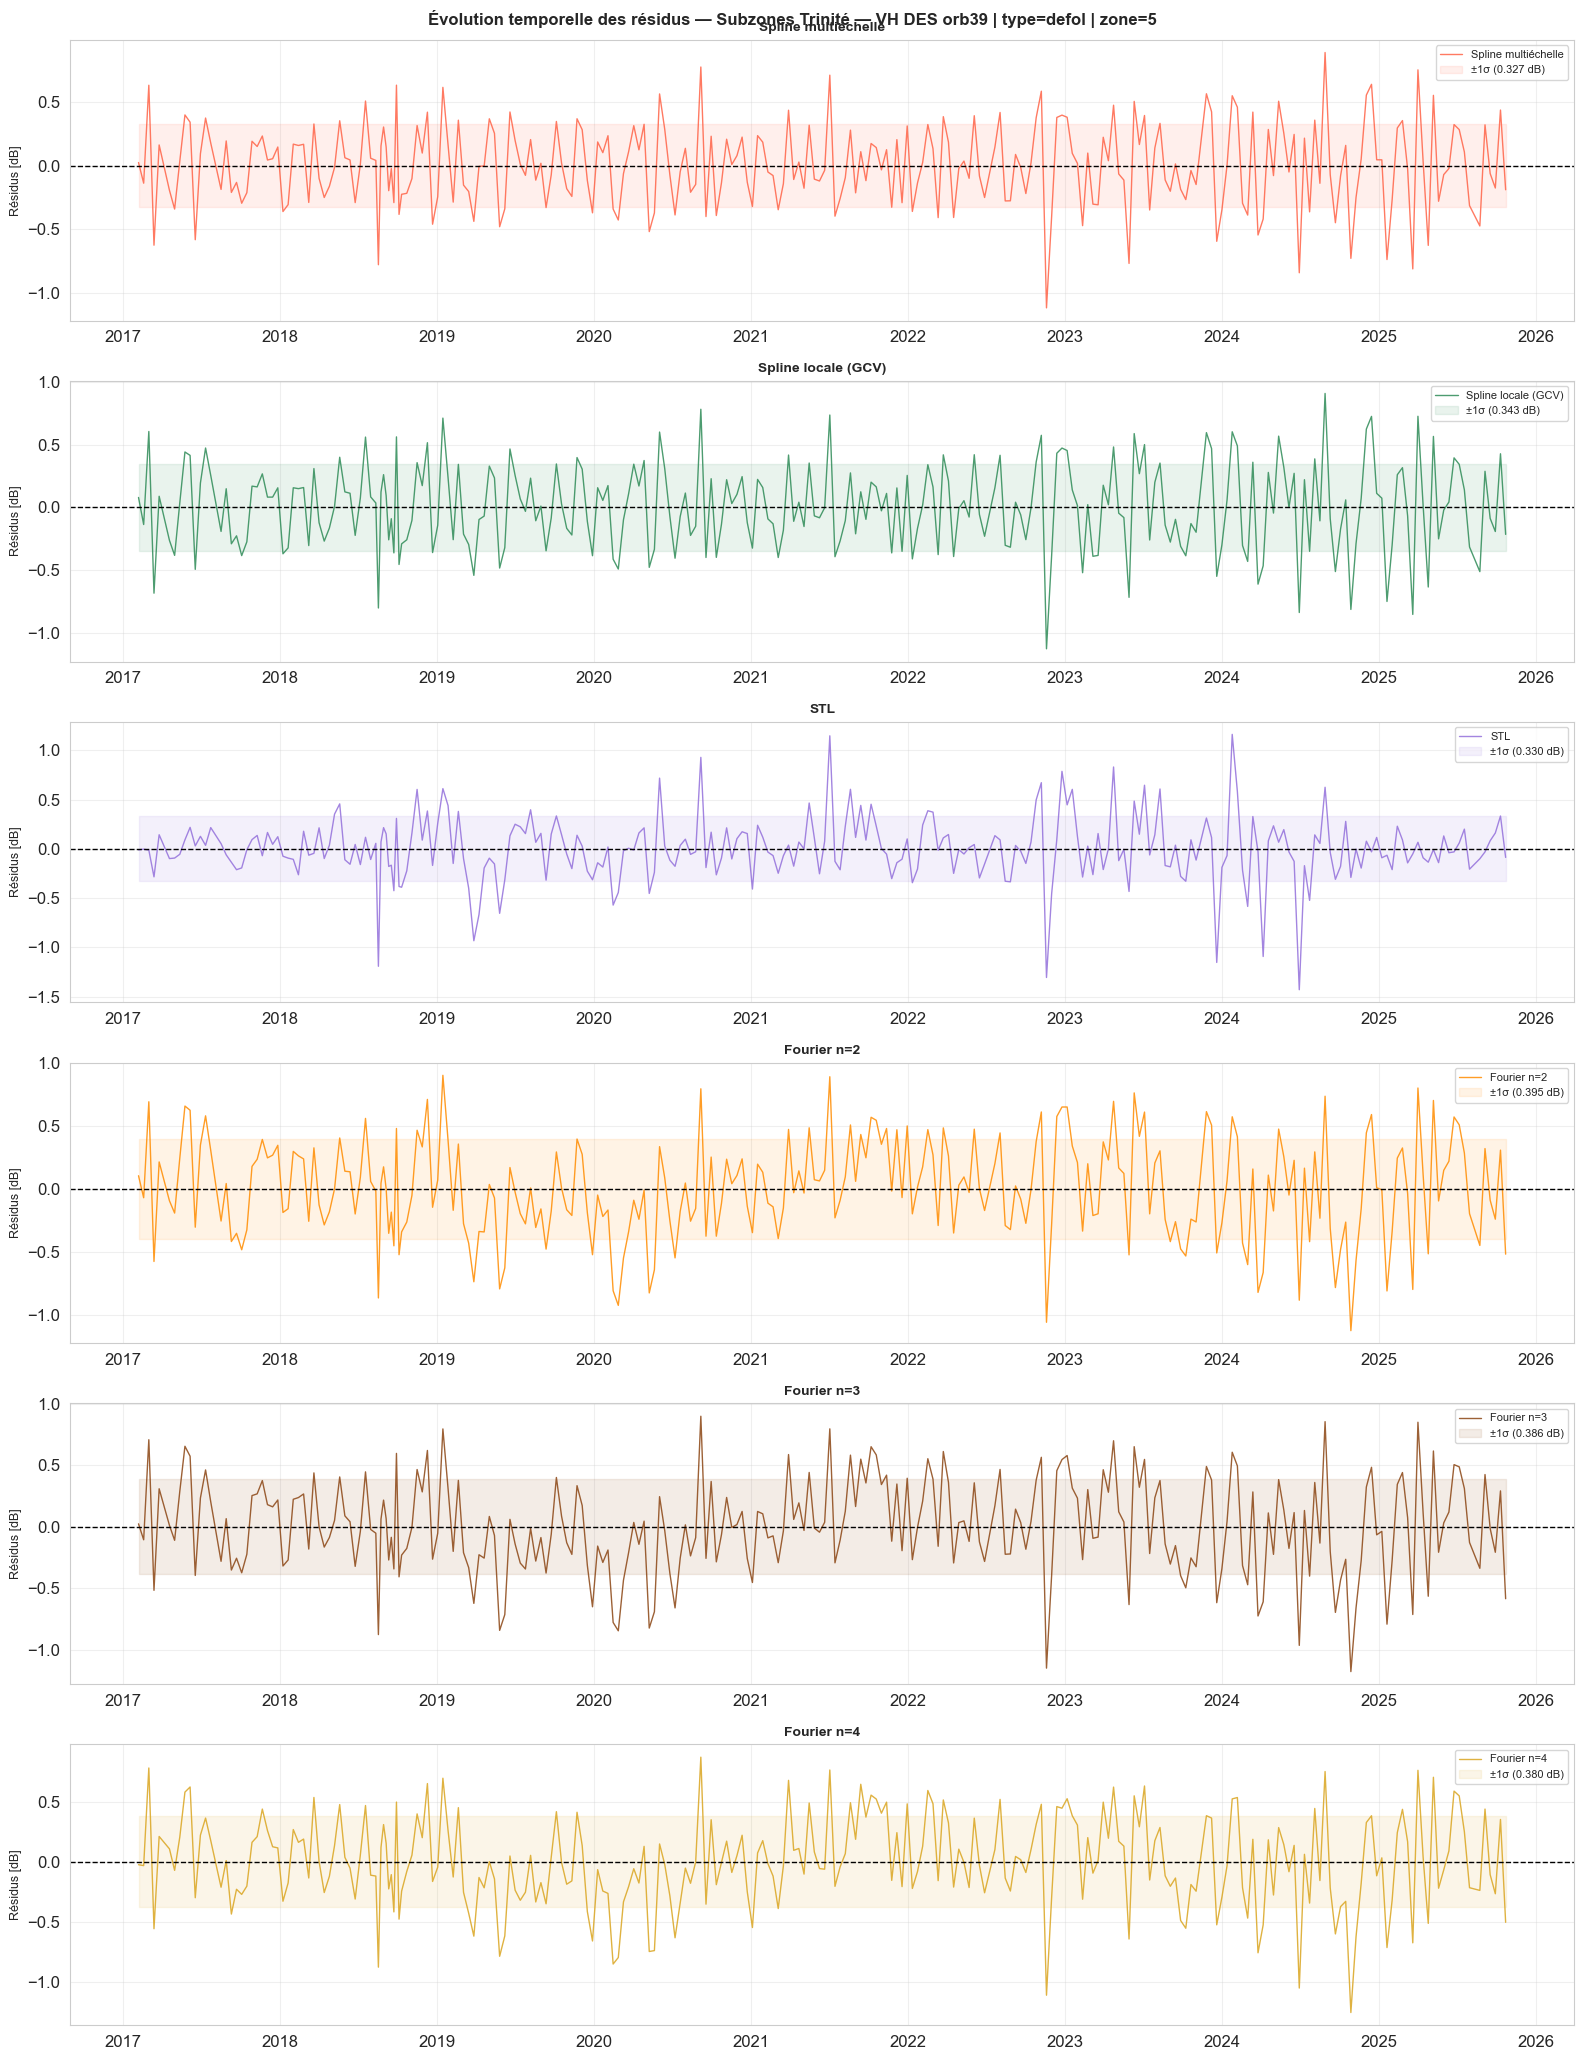

In [9]:
fig, axes = plt.subplots(1, n_methods, figsize=(6 * n_methods, 5))
if n_methods == 1: axes = [axes]

for ax, (name, res), color in zip(axes, residuals.items(), colors_list):
    lb_p = results["metrics"][name]["Ljung-Box p_min"]
    plot_acf(res, lags=min(30, len(res)//2 - 1), ax=ax, alpha=0.05, color=color)
    verdict = "✓ Bruit blanc" if lb_p > 0.05 else "✗ Autocorrélé"
    ax.set_title(f"{name}\nLjung-Box p_min={lb_p:.2e}  {verdict}",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Lag"); ax.grid(True, alpha=0.3)

plt.suptitle("ACF des résidus", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures_pipeline/04_acf_residus.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Séries temporelles des résidus ───────────────────────────────────────────
fig, axes = plt.subplots(n_methods, 1, figsize=(16, 3.5 * n_methods), sharex=False)
if n_methods == 1: axes = [axes]

for ax, (name, res), color in zip(axes, residuals.items(), colors_list):
    ax.plot(dates, res, lw=1.0, color=color, alpha=0.85, label=name)
    ax.axhline(0, color="black", ls="--", lw=1)
    ax.fill_between(dates, -res.std(), res.std(), alpha=0.10, color=color,
                    label=f"±1σ ({res.std():.3f} dB)")
    ax.set_ylabel("Résidus [dB]", fontsize=9)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.legend(fontsize=8, loc="upper right"); ax.grid(True, alpha=0.3)

plt.suptitle(f"Évolution temporelle des résidus — {results['label']}",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("figures_pipeline/05_temporal_residus.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Tableau récapitulatif final

Consolidation de **tous** les critères de comparaison en un seul tableau ordonné par R² décroissant.


In [10]:
# ── Construction du DataFrame ───────────────────────────────────────────────
COL_ORDER = [
    "R²", "RMSE [dB]", "σ résidus [dB]", "μ résidus [dB]",
    "Corrélation r", "r / std", "Amplitude [dB]",
    "Shapiro W", "Shapiro p", "Gaussien (p>0.05)",
    "Ljung-Box p_min", "Bruit blanc (p>0.05)",
]

rows = []
for name, m in results["metrics"].items():
    row = {"Méthode": name}
    row.update({k: m[k] for k in COL_ORDER})
    rows.append(row)

df = pd.DataFrame(rows).set_index("Méthode")

# Tri par R² décroissant
df_sorted = df.copy()
df_sorted["_r2_num"] = pd.to_numeric(df_sorted["R²"], errors="coerce")
df_sorted = df_sorted.sort_values("_r2_num", ascending=False).drop(columns="_r2_num")

# Formatage pour affichage
df_display = df_sorted.copy()
for col in ["R²", "RMSE [dB]", "σ résidus [dB]", "μ résidus [dB]",
            "Corrélation r", "r / std", "Amplitude [dB]",
            "Shapiro W"]:
    df_display[col] = df_display[col].apply(
        lambda v: f"{v:.4f}" if isinstance(v, (int, float)) and not np.isnan(v) else "—")
for col in ["Shapiro p", "Ljung-Box p_min"]:
    df_display[col] = df_display[col].apply(
        lambda v: f"{v:.2e}" if isinstance(v, (int, float)) and not np.isnan(v) else "—")

print("\n" + "="*90)
print(f"  TABLEAU RÉCAPITULATIF — {results['label']}")
print("="*90)
display(df_display)

df_display.to_csv("figures_pipeline/recap_final.csv")
print("\n✓ Sauvegardé : figures_pipeline/recap_final.csv")



  TABLEAU RÉCAPITULATIF — Subzones Trinité — VH DES orb39 | type=defol | zone=5


,R²,RMSE [dB],σ résidus [dB],μ résidus [dB],Corrélation r,r / std,Amplitude [dB],Shapiro W,Shapiro p,Gaussien (p>0.05),Ljung-Box p_min,Bruit blanc (p>0.05)
Méthode,,,,,,,,,,,,
Spline multiéchelle,0.5735,0.3273,0.3273,0.0000,0.7587,2.1244,0.5400,0.9957,6.78e-01,✓,9.20e-07,✗
STL,0.5671,0.3298,0.3298,0.0001,0.7557,1.8423,0.7737,0.9253,2.68e-10,✗,1.04e-02,✗
Spline locale (GCV),0.5312,0.3431,0.3431,0.0000,0.7306,2.1426,0.4535,0.9952,5.74e-01,✓,1.81e-04,✗
Fourier n=4,0.4259,0.3797,0.3797,0.0000,0.6526,1.9953,0.4567,0.9896,5.34e-02,✓,8.06e-03,✗
Fourier n=3,0.4065,0.3861,0.3861,-0.0000,0.6376,1.9953,0.3893,0.9907,8.78e-02,✓,9.22e-03,✗
Fourier n=2,0.3776,0.3954,0.3954,0.0000,0.6145,1.9953,0.4463,0.9928,2.25e-01,✓,1.44e-03,✗



✓ Sauvegardé : figures_pipeline/recap_final.csv


### 9.1 Heatmap visuelle

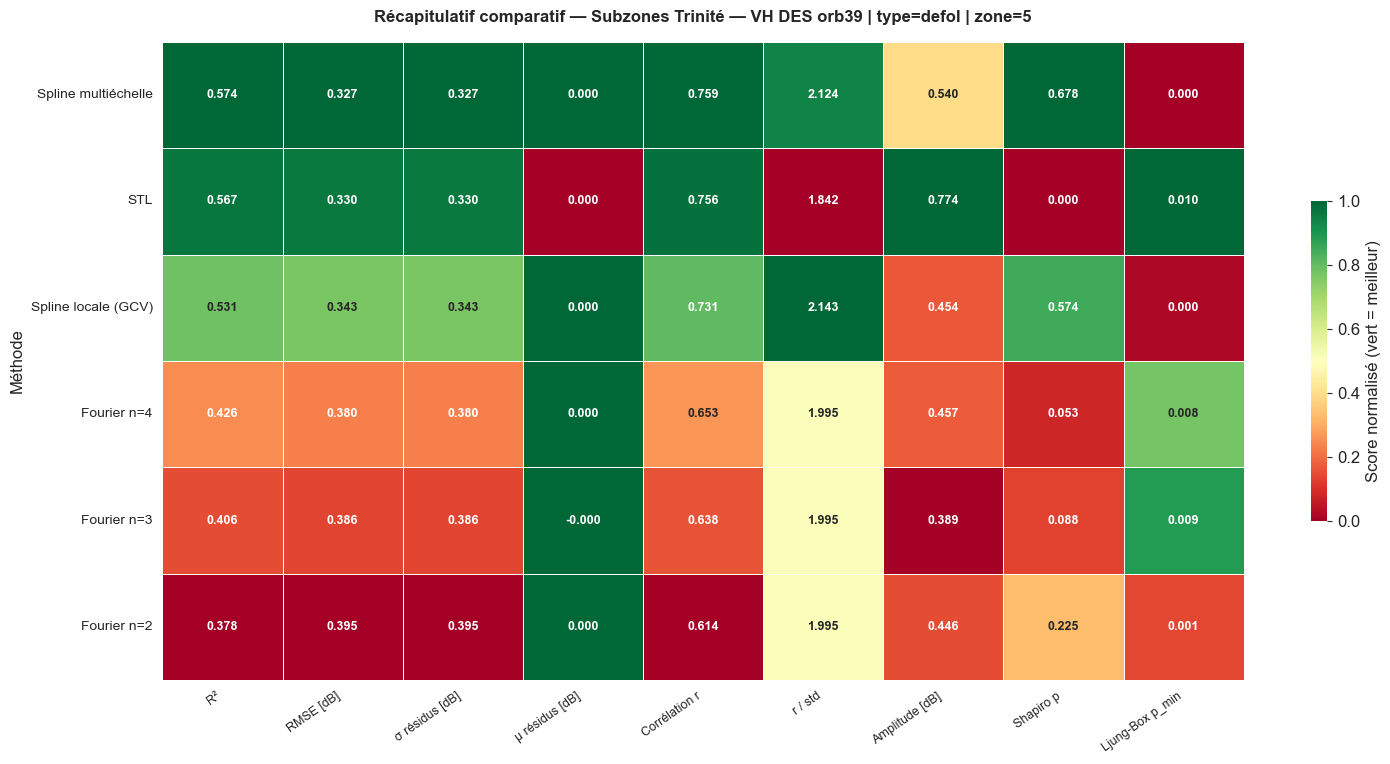


Bilan qualitatif des résidus :


,Gaussien (p>0.05),Bruit blanc (p>0.05)
Méthode,,
Spline multiéchelle,✓,✗
STL,✗,✗
Spline locale (GCV),✓,✗
Fourier n=4,✓,✗
Fourier n=3,✓,✗
Fourier n=2,✓,✗


In [11]:
# ── Données numériques pour la heatmap ──────────────────────────────────────
NUM_COLS = ["R²", "RMSE [dB]", "σ résidus [dB]", "μ résidus [dB]",
            "Corrélation r", "r / std", "Amplitude [dB]",
            "Shapiro p", "Ljung-Box p_min"]

df_num = pd.DataFrame(index=df_sorted.index)
for col in NUM_COLS:
    df_num[col] = [results["metrics"][m][col] for m in df_sorted.index]
df_num = df_num.apply(pd.to_numeric, errors="coerce")

# Normalisation colonne par colonne (0=pire, 1=meilleur)
df_norm = df_num.copy()
for col in df_norm.columns:
    mn, mx = df_norm[col].min(), df_norm[col].max()
    if mx > mn:
        df_norm[col] = (df_norm[col] - mn) / (mx - mn)
    else:
        df_norm[col] = 0.5
# Inverser les colonnes "plus petit = mieux"
for col in ["RMSE [dB]", "σ résidus [dB]"]:
    if col in df_norm.columns:
        df_norm[col] = 1 - df_norm[col]
# |μ résidus| : plus proche de 0 = mieux
df_norm["μ résidus [dB]"] = 1 - df_norm["μ résidus [dB]"].abs()
# p-values : plus grand = mieux (déjà dans le bon sens)

annot = df_num.applymap(lambda v: f"{v:.3f}" if not np.isnan(v) else "—")

fig, ax = plt.subplots(figsize=(len(NUM_COLS) * 1.6 + 1, len(df_norm) + 1.8))
sns.heatmap(df_norm, ax=ax, annot=annot, fmt="",
            cmap="RdYlGn", vmin=0, vmax=1,
            linewidths=0.4, linecolor="white",
            cbar_kws={"label": "Score normalisé (vert = meilleur)", "shrink": 0.5},
            annot_kws={"size": 9, "weight": "bold"})
ax.set_title(f"Récapitulatif comparatif — {results['label']}",
             fontsize=12, fontweight="bold", pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig("figures_pipeline/06_heatmap_recap.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Tableau binaire Gaussien / Bruit blanc ────────────────────────────────────
print("\nBilan qualitatif des résidus :")
display(df_sorted[["Gaussien (p>0.05)", "Bruit blanc (p>0.05)"]])


### 9.2 Graphe radar — profil de performance

Comparaison visuelle multi-critères sous forme de toile d'araignée.
Chaque axe est normalisé entre 0 (pire) et 1 (meilleur).


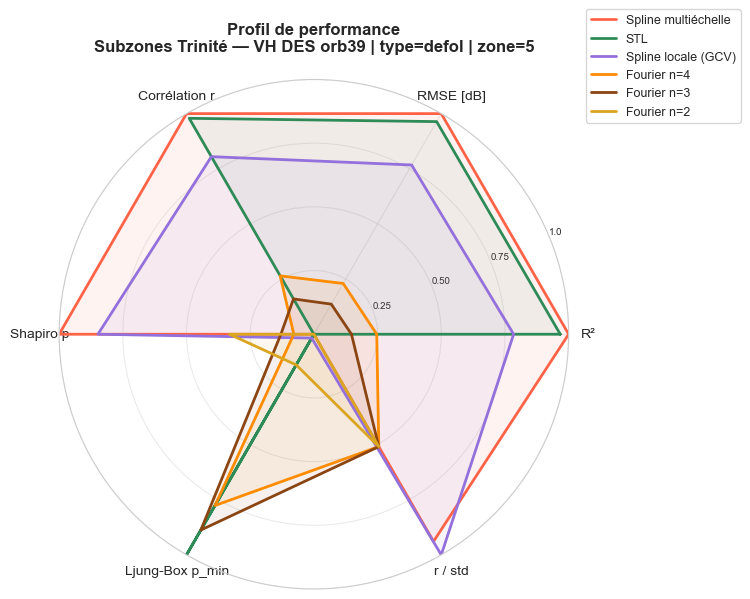

In [12]:
RADAR_COLS = {
    "R²"            : True,   # True = grand est mieux, False = petit est mieux
    "RMSE [dB]"     : False,
    "Corrélation r" : True,
    "Shapiro p"     : True,
    "Ljung-Box p_min": True,
    "r / std"       : True,
}

# Construction des scores normalisés
scores = {}
raw    = {col: np.array([results["metrics"][m][col] for m in df_sorted.index], dtype=float)
          for col in RADAR_COLS}
for col, higher_better in RADAR_COLS.items():
    mn, mx = np.nanmin(raw[col]), np.nanmax(raw[col])
    if mx > mn:
        norm = (raw[col] - mn) / (mx - mn)
    else:
        norm = np.full(len(raw[col]), 0.5)
    scores[col] = norm if higher_better else 1 - norm

categories  = list(RADAR_COLS.keys())
N_cat       = len(categories)
angles      = np.linspace(0, 2*np.pi, N_cat, endpoint=False).tolist()
angles     += angles[:1]  # boucler
method_list = list(df_sorted.index)

RADAR_COLORS = ["tomato","seagreen","mediumpurple","darkorange","saddlebrown","goldenrod","steelblue"]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "polar"})

for i, method in enumerate(method_list):
    vals  = [scores[col][i] for col in categories] + [scores[categories[0]][i]]
    color = RADAR_COLORS[i % len(RADAR_COLORS)]
    ax.plot(angles, vals, lw=2, color=color, label=method)
    ax.fill(angles, vals, alpha=0.07, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0.25", "0.50", "0.75", "1.0"], fontsize=7)
ax.grid(True, alpha=0.4)
ax.set_title(f"Profil de performance\n{results['label']}",
             fontsize=12, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)

plt.tight_layout()
plt.savefig("figures_pipeline/07_radar.png", dpi=150, bbox_inches="tight")
plt.show()
